## 🏨 Hospitality Revenue Analysis — AtliQ Grands
**Dataset:** May 2022 – July 2022 (92 days)  
**Tools Used:** Python (Pandas, Matplotlib, Seaborn) | SQL (SQLite via sqlite3)  
**Objective:** Analyze revenue performance across cities and properties, identify causes of 
declining market share, and provide actionable business recommendations.

**Tables Used:**
- `dim_hotels` — property master data
- `dim_rooms` — room classification
- `dim_date` — calendar table
- `fact_booking` — transaction-level booking records (134,590 rows)
- `fact_aggregated_bookings` — daily room-level capacity & bookings

## 🏨 Problem Statement
AtliQ Grands is a luxury hotel chain operating across 4 cities in India — Mumbai, Delhi, Hyderabad, and Bangalore.
Due to increasing competition and poor management decisions, the company is losing market share and revenue. The management has no visibility into what's happening across their properties.
They have hired you as a Data Analyst to analyze their historical booking data and answer key business questions so they can take corrective action.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
os.getcwd()

'/Users/sarveshsatyawangaikwad/Documents/Projects DA/ATLIQ Hosptiality DA project/DATA'

In [5]:
os.listdir()

['Hospitality Project.ipynb',
 'dim_hotels.csv',
 'fact_bookings.csv',
 'dim_rooms.csv',
 'hospitality.db',
 'dim_date.csv',
 '.ipynb_checkpoints',
 'fact_aggregated_bookings.csv']

In [6]:
dim_hotels = pd.read_csv("dim_hotels.csv")
dim_rooms = pd.read_csv("dim_rooms.csv")
dim_date = pd.read_csv("dim_date.csv")
fact_booking = pd.read_csv("fact_bookings.csv")
fact_aggregated_bookings = pd.read_csv("fact_aggregated_bookings.csv")

### DATA UNDERSTANDING

In [7]:
# dim_hotels

In [8]:
dim_hotels.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [9]:
dim_hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   property_id    25 non-null     int64 
 1   property_name  25 non-null     object
 2   category       25 non-null     object
 3   city           25 non-null     object
dtypes: int64(1), object(3)
memory usage: 932.0+ bytes


In [10]:
dim_hotels.isnull().sum()

property_id      0
property_name    0
category         0
city             0
dtype: int64

In [11]:
dim_hotels[dim_hotels.duplicated()]

,property_id,property_name,category,city


In [12]:
dim_hotels.columns

Index(['property_id', 'property_name', 'category', 'city'], dtype='object')

In [13]:
dim_hotels["property_id"].unique()

array([16558, 16559, 16560, 16561, 16562, 16563, 17558, 17559, 17560,
       17561, 17562, 17563, 18558, 18559, 18560, 18561, 18562, 18563,
       19558, 19559, 19560, 19561, 19562, 19563, 17564])

In [14]:
dim_hotels["property_id"].nunique()

25

In [15]:
dim_hotels["property_name"].value_counts()

property_name
Atliq Grands     4
Atliq Exotica    4
Atliq City       4
Atliq Blu        4
Atliq Bay        4
Atliq Palace     4
Atliq Seasons    1
Name: count, dtype: int64

In [16]:
dim_hotels["category"].unique()

array(['Luxury', 'Business'], dtype=object)

In [17]:
dim_hotels["city"].unique()

array(['Delhi', 'Mumbai', 'Hyderabad', 'Bangalore'], dtype=object)

In [18]:
dim_hotels.groupby('city')['property_name'].count().reset_index(name='Property count')

,city,Property count
0,Bangalore,6
1,Delhi,5
2,Hyderabad,6
3,Mumbai,8


**Observtaion - dim_hotels**
1. dim_hotels contains property infromation with 4 columns - 'property_id', 'property_name', 'category', 'city'
2. The table has 25 records(property_id) repersenting 7 unique properties across 4 cities in india.
3. Mumbai leads with the highest number of properties (8), followed by Bangalore and Hyderabad (6 each), while Delhi has the fewest(5)
4. No null values or duplicates found.
5. property_id is currently int64 — should be converted to object since it is an identifier, not a numeric value used for calculations

In [19]:
# dim_rooms

In [20]:
dim_rooms.head()

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [21]:
dim_rooms["room_class"].unique()

array(['Standard', 'Elite', 'Premium', 'Presidential'], dtype=object)

**Observation -  dim_rooms**
1. dim_rooms contains room classification information with 2 columns — room_id and room_class
2. Room class consisting of 4 categories — Standard, Elite, Premium, and Presidential.  
3. No null values, duplicates, or dtype issues found.

In [22]:
# dim_date

In [23]:
dim_date.head()

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [24]:
dim_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      92 non-null     object
 1   mmm yy    92 non-null     object
 2   week no   92 non-null     object
 3   day_type  92 non-null     object
dtypes: object(4)
memory usage: 3.0+ KB


In [25]:
dim_date.rename(columns={"week no": "week_no"}, inplace=True)

In [26]:
dim_date.columns

Index(['date', 'mmm yy', 'week_no', 'day_type'], dtype='object')

In [27]:
print("First date:",min(dim_date["date"]))
print("LAST date:",max(dim_date["date"]))

First date: 01-Jul-22
LAST date: 31-May-22


**Observation - dim_date**
1. dim_date is a calendar table with 4 columns — date, mmm_yy, week_no, and day_type
2. The date column is currently stored as object — needs to be converted to datetime64 to enable time-based analysis
3. day_type requires correction based on hospitality domain knowledge — in the hotel industry, Friday and Saturday are considered weekend, unlike the standard Saturday-Sunday definition
4. Additional date features such as month, year, and day can be extracted from the date column for deeper time-series analysis.

In [28]:
# fact_booking - transcation table

In [29]:
fact_booking.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,2022-04-27,2022-05-01,2022-05-02,3,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,2022-04-28,2022-05-01,2022-05-04,2,RT1,logtrip,5.0,Checked Out,9100,9100
3,May012216558RT14,16558,2022-04-28,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4,RT1,direct online,5.0,Checked Out,10920,10920


In [30]:
fact_booking.shape

(134590, 12)

In [31]:
fact_booking.columns

Index(['booking_id', 'property_id', 'booking_date', 'check_in_date',
       'checkout_date', 'no_guests', 'room_category', 'booking_platform',
       'ratings_given', 'booking_status', 'revenue_generated',
       'revenue_realized'],
      dtype='object')

**Observation**
- fact_bookings is the primary booking transaction table consisting of 134,590 records and 12 columns — booking_id, property_id, booking_date, check_in_date, checkout_date, no_guests, room_category, booking_platform, ratings_given, booking_status, revenue_generated, and revenue_realized

In [32]:
fact_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134590 non-null  object 
 1   property_id        134590 non-null  int64  
 2   booking_date       134590 non-null  object 
 3   check_in_date      134590 non-null  object 
 4   checkout_date      134590 non-null  object 
 5   no_guests          134590 non-null  int64  
 6   room_category      134590 non-null  object 
 7   booking_platform   134590 non-null  object 
 8   ratings_given      56683 non-null   float64
 9   booking_status     134590 non-null  object 
 10  revenue_generated  134590 non-null  int64  
 11  revenue_realized   134590 non-null  int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 12.3+ MB


**Observation**
1. All three date columns — booking_date, check_in_date, and checkout_date — are currently stored as object and need to be converted to datetime64
2. ratings_given shows only 56,683 non-null records out of 134,590 — confirming missing values exist

In [33]:
fact_booking[fact_booking.duplicated()]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized


In [34]:
fact_booking.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77907
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

In [35]:
rating_given_null_pct = fact_booking["ratings_given"].isnull().sum()/len(fact_booking)*100
rating_given_null_pct

np.float64(57.884686826658736)

In [36]:
fact_booking["ratings_given"].astype("str").value_counts()

ratings_given
nan    77907
5.0    19480
3.0    17561
4.0     9653
2.0     6452
1.0     3537
Name: count, dtype: int64

**Observation**
1. No duplicate records found ✅
2. ratings_given has 77,907 null values — approximately 57% of total records
3. This column requires special treatment — filling method needs to be decided before analysis

In [37]:
fact_booking["booking_status"].unique()

array(['Checked Out', 'Cancelled', 'No Show'], dtype=object)

In [38]:
fact_booking[["revenue_generated","revenue_realized"]].describe()

,revenue_generated,revenue_realized
count,134590.000000,134590.000000
mean,14916.013188,12696.123256
std,6452.868072,6928.108124
min,6500.000000,2600.000000
25%,9900.000000,7600.000000
50%,13500.000000,11700.000000
75%,18000.000000,15300.000000
max,45220.000000,45220.000000


**Observation**
1. revenue_generated = expected revenue
2. revenue_realized = actual collected revenue
3. On average, AtliQ loses approximately ₹2,220 per booking between expected and actual revenue
4. Both min and max values drop from generated to realized — confirming revenue leakage at every level
5. revenue_realized has a higher standard deviation (₹6,928) compared to revenue_generated (₹6,452) — meaning actual collections are more unpredictable than expected revenue

In [39]:
fact_aggregated_bookings

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,01-May-22,RT1,25,30
1,19562,01-May-22,RT1,28,30
2,19563,01-May-22,RT1,23,30
3,17558,01-May-22,RT1,13,19
4,16558,01-May-22,RT1,18,19
...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18
9196,16559,31-Jul-22,RT4,13,18
9197,17558,31-Jul-22,RT4,3,6
9198,19563,31-Jul-22,RT4,3,6


In [40]:
fact_aggregated_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   property_id          9200 non-null   int64 
 1   check_in_date        9200 non-null   object
 2   room_category        9200 non-null   object
 3   successful_bookings  9200 non-null   int64 
 4   capacity             9200 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 359.5+ KB


In [41]:
fact_aggregated_bookings.duplicated().sum()

np.int64(0)

In [42]:
fact_aggregated_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               0
dtype: int64

In [43]:
fact_aggregated_bookings.describe()

,property_id,successful_bookings,capacity
count,9200.000000,9200.000000,9200.000000
mean,18040.640000,14.629348,25.280000
std,1099.818325,7.591770,11.440971
min,16558.000000,1.000000,3.000000
25%,17558.000000,9.000000,18.000000
50%,17564.000000,14.000000,25.000000
75%,18563.000000,19.000000,34.000000
max,19563.000000,43.000000,50.000000


In [44]:
fact_aggregated_bookings[
    fact_aggregated_bookings['successful_bookings'] > fact_aggregated_bookings['capacity']
]

,property_id,check_in_date,room_category,successful_bookings,capacity


**Observation - fact_aggregated_bookings**
1. fact_aggregated_bookings contains daily room-level booking data consisting of 9,200 records and 5 columns — property_id, check_in_date, room_category, successful_bookings, and capacity
2. check_in_date is currently stored as object — needs to be converted to datetime64 for date-based analysis
3. No null values or duplicate records found — table is clean and ready for analysis
4. On average 14.6 rooms are booked out of 25.2 available capacity per day — meaning roughly 42% of rooms go empty daily successful_bookings ranges from 1 to 43 and capacity from 3 to 50 — showing significant variation across properties.
5. This directly connects to the business problem — low occupancy = direct revenue loss every night

### DATA CLEANING

**DATA CLEANING**
Five cleaning tasks identified during Data Understanding phase:
- `dim_hotels` — property_id converted from int64 to object
- `fact_aggregated_bookings` — property_id to object, check_in_date to datetime
- `fact_booking` — booking_date, check_in_date, checkout_date converted to datetime
- `dim_date` — date converted to datetime, day_type corrected (Fri + Sat = Weekend)
- `fact_booking` — ratings_given nulls retained as-is (57.88% missing, cannot be imputed)

In [45]:
dim_hotels["property_id"].dtype

dtype('int64')

In [46]:
dim_hotels["property_id"] = dim_hotels["property_id"].astype("str")
dim_hotels.dtypes

property_id      object
property_name    object
category         object
city             object
dtype: object

Done — property_id converted to: object

In [47]:
fact_aggregated_bookings.dtypes

property_id             int64
check_in_date          object
room_category          object
successful_bookings     int64
capacity                int64
dtype: object

In [48]:
fact_aggregated_bookings["property_id"] = fact_aggregated_bookings["property_id"].astype("str")
fact_aggregated_bookings["check_in_date"] = pd.to_datetime(fact_aggregated_bookings["check_in_date"], format="%d-%b-%y")

In [49]:
fact_aggregated_bookings.dtypes # Aftee change 

property_id                    object
check_in_date          datetime64[ns]
room_category                  object
successful_bookings             int64
capacity                        int64
dtype: object

Done — fact_aggregated_bookings | 
property_id converted to: object | 
check_in_date converted to : datetime64[ns]

In [50]:
fact_booking.dtypes

booking_id            object
property_id            int64
booking_date          object
check_in_date         object
checkout_date         object
no_guests              int64
room_category         object
booking_platform      object
ratings_given        float64
booking_status        object
revenue_generated      int64
revenue_realized       int64
dtype: object

In [51]:
fact_booking["booking_date"] = pd.to_datetime(fact_booking["booking_date"],format="%Y-%m-%d")
fact_booking["check_in_date"] = pd.to_datetime(fact_booking["check_in_date"],format="%Y-%m-%d")
fact_booking["checkout_date"] = pd.to_datetime(fact_booking["checkout_date"],format="%Y-%m-%d")
fact_booking["property_id"] = fact_booking["property_id"].astype("str")

In [52]:
fact_booking.dtypes

booking_id                   object
property_id                  object
booking_date         datetime64[ns]
check_in_date        datetime64[ns]
checkout_date        datetime64[ns]
no_guests                     int64
room_category                object
booking_platform             object
ratings_given               float64
booking_status               object
revenue_generated             int64
revenue_realized              int64
dtype: object

All 3 date columns successfully converted to datetime64

In [53]:
dim_date.head()

,date,mmm yy,week_no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [54]:
dim_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      92 non-null     object
 1   mmm yy    92 non-null     object
 2   week_no   92 non-null     object
 3   day_type  92 non-null     object
dtypes: object(4)
memory usage: 3.0+ KB


In [55]:
dim_date["date"] = pd.to_datetime(dim_date["date"],format = "%d-%b-%y")

In [56]:
print("Last Date:",dim_date["date"].max())
print("Start Date:",dim_date["date"].min())

Last Date: 2022-07-31 00:00:00
Start Date: 2022-05-01 00:00:00


In [57]:
dim_date["weekday"] = dim_date["date"].dt.dayofweek

In [58]:
dim_date.head()

,date,mmm yy,week_no,day_type,weekday
0,2022-05-01,May 22,W 19,weekend,6
1,2022-05-02,May 22,W 19,weekeday,0
2,2022-05-03,May 22,W 19,weekeday,1
3,2022-05-04,May 22,W 19,weekeday,2
4,2022-05-05,May 22,W 19,weekeday,3


In [59]:
dim_date["day_type"] = dim_date["date"].dt.dayofweek.apply(
    lambda x: "Weekend" if x in [4,5] else "Weekday")

In [60]:
dim_date.drop(columns=["weekday"],inplace=True)

In [61]:
dim_date.head()

,date,mmm yy,week_no,day_type
0,2022-05-01,May 22,W 19,Weekday
1,2022-05-02,May 22,W 19,Weekday
2,2022-05-03,May 22,W 19,Weekday
3,2022-05-04,May 22,W 19,Weekday
4,2022-05-05,May 22,W 19,Weekday


dim date Weekday - Weekend( friday , saturday) correction done

In [62]:
fact_booking.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,2022-04-27,2022-05-01,2022-05-02,3,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,2022-04-28,2022-05-01,2022-05-04,2,RT1,logtrip,5.0,Checked Out,9100,9100
3,May012216558RT14,16558,2022-04-28,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4,RT1,direct online,5.0,Checked Out,10920,10920


In [63]:
null_value_rating = fact_booking["ratings_given"].isnull().sum()
null_value_rating

np.int64(77907)

In [64]:
null_perct = (null_value_rating/len(fact_booking))*100
print(f"{null_perct:.2f}% ({null_value_rating}) null values found in fact_booking ratings_given column")

57.88% (77907) null values found in fact_booking ratings_given column


**OBSERVATION :**
ratings_given column has 57.88% null values (77,907 out of 134,590 records) — which is more than half the dataset. Filling such a large gap with mean or mode would introduce fake ratings and corrupt the analysis. Since customer ratings are subjective and cannot be guessed, nulls are retained as is. Any rating-based analysis will be performed only on available records.

In [65]:
cancel_booking = fact_booking[fact_booking["booking_status"]=="Cancelled"]
cancel_booking.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
3,May012216558RT14,16558,2022-04-28,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
6,May012216558RT17,16558,2022-04-28,2022-05-01,2022-05-06,2,RT1,others,NaN,Cancelled,9100,3640
13,May012216558RT114,16558,2022-04-30,2022-05-01,2022-05-05,1,RT1,logtrip,NaN,Cancelled,9100,3640
21,May012216558RT24,16558,2022-04-29,2022-05-01,2022-05-03,3,RT2,others,NaN,Cancelled,13860,5544


**📝 Notes & Future Scope**

- **Cancellation deep-dive:** Cancellation revenue behaviour was identified during data 
  cleaning — cancelled bookings recover only 40% of expected revenue through penalties. 
  A more detailed cancellation analysis (by lead time, room class, guest type) can be 
  done with additional data.

- **Ratings analysis:** ratings_given is available for 43% of bookings. A dedicated 
  customer satisfaction analysis can be done once rating collection improves across 
  all booking channels.

### ANALYSIS

In [67]:
import sqlite3

In [68]:
# Create a database file
conn = sqlite3.connect("hospitality.db")
print("Database created!")

Database created!


In [69]:
# Load all tables to database
dim_hotels.to_sql("dim_hotels", conn, index=False, if_exists="replace")
dim_date.to_sql("dim_date",conn,index=False,if_exists="replace")
dim_rooms.to_sql("dim_rooms",conn,index=False,if_exists="replace")
fact_booking.to_sql("fact_booking",conn,index=False,if_exists="replace")
fact_aggregated_bookings.to_sql("fact_aggregated_bookings",conn,index=False,if_exists="replace")

9200

In [70]:
# check tables loaded or not ??
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'",conn).reset_index()
print(tables)

   index                      name
0      0                dim_hotels
1      1                  dim_date
2      2                 dim_rooms
3      3              fact_booking
4      4  fact_aggregated_bookings


In [71]:
query_1 = """
SELECT min(date) AS first_day , max(date) As last_day FROM dim_date
"""
date_FromTo = pd.read_sql(query_1,conn)
date_FromTo

,first_day,last_day
0,2022-05-01 00:00:00,2022-07-31 00:00:00


**Observation**
The dataset contains hotel booking records spanning 3 months — from May 2022 to July 2022, covering a total of 92 days of operational data across all AtliQ properties.

In [72]:
# Total Revenue realized
query_2 = """
SELECT 
ROUND(SUM(revenue_realized) / 100000, 2) AS revenue_lakhs
FROM fact_booking
;
"""
Total_revenue_realized  = pd.read_sql(query_2,conn).iloc[0,0]
print(f"Actual revnenue generted from may-22 to july 22 in 92 days is {Total_revenue_realized} lakhs")

Actual revnenue generted from may-22 to july 22 in 92 days is 17087.0 lakhs


In [73]:
query_3 = """
WITH hotel_count AS (
    SELECT city , COUNT(property_name) AS city_property_count FROM dim_hotels
    GROUP BY city
    ORDER BY city_property_count DESC
),

hotel_revenue AS (
    SELECT H.city, ROUND(SUM(B.revenue_realized)/100000,2) AS city_property_revenue
    FROM dim_hotels H
    JOIN fact_booking B 
    ON H.property_id = B.property_id
    GROUP BY H.city 
    ORDER BY city_property_revenue
)
SELECT C.city , C.city_property_count , R.city_property_revenue 
FROM hotel_count AS C
JOIN hotel_revenue AS R 
ON C.city = R.city
ORDER BY R.city_property_revenue DESC

"""
city_revenue_summary = pd.read_sql(query_3,conn)
city_revenue_summary

,city,city_property_count,city_property_revenue
0,Mumbai,8,6686.0
1,Bangalore,6,4203.0
2,Hyderabad,6,3252.0
3,Delhi,5,2945.0


**Observation :**
Mumbai leads with ₹6,686 Lakhs in realized revenue across 8 properties, while Delhi generates ₹2,945 Lakhs across 5 properties. However, comparing total revenue across cities is misleading since each city has a different number of hotels. A fair comparison requires revenue per hotel — which will reveal which city's individual properties are actually performing better.

In [74]:
extra_query = """
WITH hotel_count AS (
    SELECT city , COUNT(property_name) AS city_property_count FROM dim_hotels
    GROUP BY city
    ORDER BY city_property_count DESC
),

hotel_revenue AS (
    SELECT H.city, ROUND(SUM(B.revenue_realized)/100000,2) AS city_property_revenue
    FROM dim_hotels H
    JOIN fact_booking B 
    ON H.property_id = B.property_id
    GROUP BY H.city 
    ORDER BY city_property_revenue
)
SELECT 
    C.city,
    C.city_property_count,
    R.city_property_revenue,
    ROUND(R.city_property_revenue / C.city_property_count, 2) 
        AS revenue_per_hotel_lakhs
FROM hotel_count AS C
JOIN hotel_revenue AS R
ON C.city = R.city
ORDER BY revenue_per_hotel_lakhs DESC

"""
city_performance  = pd.read_sql(extra_query,conn)
city_performance 

,city,city_property_count,city_property_revenue,revenue_per_hotel_lakhs
0,Mumbai,8,6686.0,835.75
1,Bangalore,6,4203.0,700.50
2,Delhi,5,2945.0,589.00
3,Hyderabad,6,3252.0,542.00


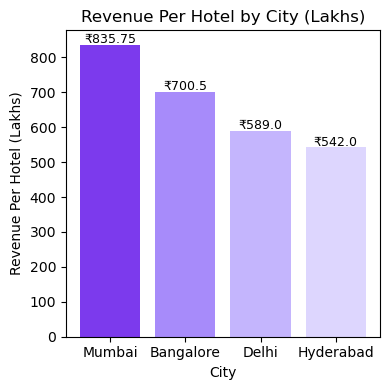

In [75]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4,4))
ax.bar(city_performance["city"], 
       city_performance["revenue_per_hotel_lakhs"],
       color=["#7c3aed","#a78bfa","#c4b5fd","#ddd6fe"])

ax.set_title("Revenue Per Hotel by City (Lakhs)")
ax.set_xlabel("City")
ax.set_ylabel("Revenue Per Hotel (Lakhs)")

for i, v in enumerate(city_performance["revenue_per_hotel_lakhs"]):
    ax.text(i, v + 5, f"₹{v}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [76]:
max_revenue = max(city_performance["revenue_per_hotel_lakhs"])
city_performance["Percantge_drop"] = city_performance["revenue_per_hotel_lakhs"].apply(
    lambda x:round((max_revenue - x)/max_revenue*100,1)
)
city_performance

,city,city_property_count,city_property_revenue,revenue_per_hotel_lakhs,Percantge_drop
0,Mumbai,8,6686.0,835.75,0.0
1,Bangalore,6,4203.0,700.50,16.2
2,Delhi,5,2945.0,589.00,29.5
3,Hyderabad,6,3252.0,542.00,35.1


**OBSERVATION :**
On a per-hotel basis, **Mumbai** leads with the highest realized revenue of **₹835.75 Lakhs per property**, followed by **Bangalore at ₹700.50 Lakhs — a 16.2% drop compared to Mumbai**. However, **Delhi (₹589 Lakhs, Drop 29.5%)** and **Hyderabad (₹542 Lakhs, Drop 35.1%)** show significant underperformance. AtliQ management should prioritize revenue improvement strategies in Delhi and Hyderabad, as these cities show the steepest decline in per-property revenue realization.

In [77]:
query_4 = """
SELECT
h.category,ROUND(SUM(b.revenue_realized)/100000) AS revenue_by_category
FROM dim_hotels AS h
JOIN fact_booking AS b
ON h.property_id = b.property_id
GROUP BY h.category
ORDER BY b.revenue_realized DESC
"""
category_revenue = pd.read_sql(query_4,conn)
category_revenue

,category,revenue_by_category
0,Luxury,10527.0
1,Business,6560.0


**OBSERVATION:**
Luxury category contributes 10,527 Lakhs (61.6%) versus Business at 6,560 Lakhs (38.4%) — confirming that luxury segment is the primary revenue driver for AtliQ

In [78]:
# Top 10 properties by revenue
query_5 = """
SELECT
h.property_name,ROUND(SUM(b.revenue_realized)/100000) AS revenue_by_properties
FROM dim_hotels AS h
JOIN fact_booking AS b
ON h.property_id = b.property_id
GROUP BY h.property_name
ORDER BY revenue_by_properties
LIMIT 10
"""
top_properties = pd.read_sql(query_5,conn)
top_properties

,property_name,revenue_by_properties
0,Atliq Seasons,661.0
1,Atliq Grands,2115.0
2,Atliq Bay,2600.0
3,Atliq Blu,2608.0
4,Atliq City,2858.0
5,Atliq Palace,3040.0
6,Atliq Exotica,3203.0


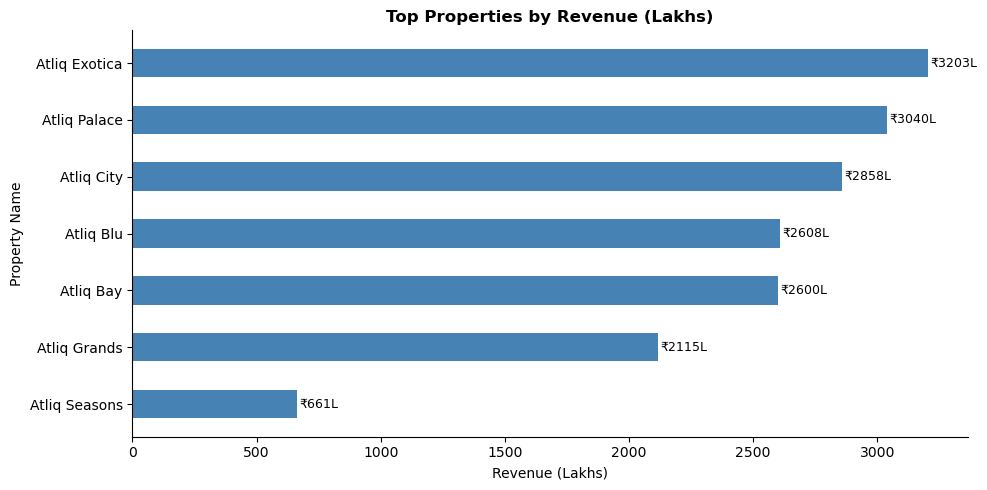

In [79]:
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(top_properties["property_name"], top_properties["revenue_by_properties"], color="steelblue",height=0.5)

# Add value labels at end of each bar
for i, v in enumerate(top_properties["revenue_by_properties"]):
    ax.text(v + 10, i, f"₹{v:.0f}L", va="center", fontsize=9)

ax.set_title("Top Properties by Revenue (Lakhs)", fontsize=12, fontweight="bold")
ax.set_xlabel("Revenue (Lakhs)")
ax.set_ylabel("Property Name")

# Remove top and right border
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**OBSEERVATION:**
Atliq Exotica leads all properties with ₹3,203 Lakhs in realized revenue, followed closely by Atliq Palace (₹3,040 Lakhs). Atliq Seasons significantly underperforms at ₹661 Lakhs — noting it operates only 1 property compared to 4 for all others, which explains the revenue gap.

In [80]:
# RevPAR Overall
# RevPAR = Revenue Per Available Room
query_6 = """
SELECT 
    SUM(revenue_realized)/(SELECT SUM(capacity) FROM fact_aggregated_bookings)
FROM fact_booking
"""
RevPAR = pd.read_sql(query_6,conn).iloc[0,0]
RevPAR = round(RevPAR)
print(f"Overall RevPAR for AtliQ Hotels (May–July 2022): ₹{RevPAR:,}")
print(f"This means on average every available room generated ₹{RevPAR:,} in revenue")

Overall RevPAR for AtliQ Hotels (May–July 2022): ₹7,347
This means on average every available room generated ₹7,347 in revenue


In [81]:
# RevPAR by property
query_7 = """
WITH revenue AS (
    SELECT 
    h.property_name,
    SUM(f.revenue_realized) AS total_revenue
    FROM dim_hotels AS h
    JOIN fact_booking AS f ON h.property_id = f.property_id
    GROUP BY h.property_name
),
capcity AS(
    SELECT
    h.property_name,
    SUM(FA.capacity) AS hotel_capacity
    FROM dim_hotels AS h
    JOIN fact_aggregated_bookings AS fa ON h.property_id = fa.property_id
    GROUP BY h.property_name
)
SELECT 
    r.property_name,r.total_revenue,c.hotel_capacity,
    r.total_revenue/c.hotel_capacity AS RevPAR_property
FROM revenue as r
JOIN capcity as c 
ON r.property_name = c.property_name
ORDER BY RevPAR_property DESC

"""
property_revpar = pd.read_sql(query_7,conn)
property_revpar

,property_name,total_revenue,hotel_capacity,RevPAR_property
0,Atliq Exotica,320312468,40940,7823
1,Atliq Palace,304081863,39376,7722
2,Atliq Blu,260855522,35144,7422
3,Atliq Seasons,66125495,8924,7409
4,Atliq City,285811939,39192,7292
5,Atliq Bay,260051178,36616,7102
6,Atliq Grands,211532764,32384,6532


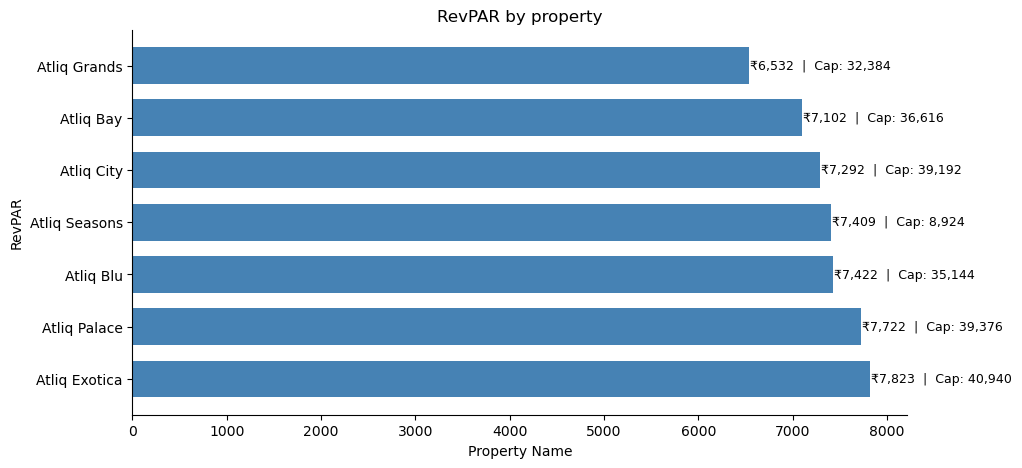

In [82]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(property_revpar["property_name"], property_revpar["RevPAR_property"], color="steelblue",height=0.7)
ax.set_title("RevPAR by property")
ax.set_xlabel("Property Name")
ax.set_ylabel("RevPAR")

for i, (v, cap) in enumerate(zip(property_revpar["RevPAR_property"],
                                  property_revpar["hotel_capacity"])):
    ax.text(v + 10, i, f"₹{v:,.0f}  |  Cap: {cap:,}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

**OBSERVATION:**
1. **Atliq Exotica** leads with the highest RevPAR of ₹7,823 across 40,940 room-nights, making it the strongest overall performer.
2. **Atliq Grands** shows the lowest RevPAR at ₹6,532 despite having 32,384 room-nights — indicating pricing or occupancy issues.
3. Notably, **Atliq Seasons**, despite having the smallest capacity (8,924 room-nights), achieves a strong RevPAR of ₹7,409 — suggesting high operational efficiency per room.

In [83]:
# ADR by room class 
# Average Daily Rate = Average price charged per booked room

In [84]:
# Total Cpacity of hotels
query_8 = """
SELECT
    SUM(capacity) AS Total_Capacity,
    SUM(successful_bookings)  AS Total_successful_bookings,
    ROUND(SUM(successful_bookings) * 100.0 / SUM(capacity), 1) AS occupancy_pct
FROM fact_aggregated_bookings
"""
hotel_capacity = pd.read_sql(query_8, conn)

In [85]:
hotel_capacity

,Total_Capacity,Total_successful_bookings,occupancy_pct
0,232576,134590,57.9


In [86]:
cap  = hotel_capacity["Total_Capacity"].iloc[0]
book = hotel_capacity["Total_successful_bookings"].iloc[0]
pct  = hotel_capacity["occupancy_pct"].iloc[0]

print(f"AtliQ Hotels have total capacity of {cap:,} room-nights, "
      f"out of which {book:,} were successfully booked "
      f"— an overall occupancy rate of {pct}%")

AtliQ Hotels have total capacity of 232,576 room-nights, out of which 134,590 were successfully booked — an overall occupancy rate of 57.9%


In [87]:
# ADR by room class 
# Average Daily Rate = Average price charged per booked room

In [88]:
query_9 = """
SELECT
    ROUND(SUM(revenue_realized) / COUNT(booking_id), 0) AS overall_ADR
FROM fact_booking
WHERE booking_status = 'Checked Out'
"""
overall_adr = pd.read_sql(query_9, conn).iloc[0, 0]
print(f"Overall ADR for AtliQ Hotels: ₹{overall_adr:,.0f}")
print(f"Note: ADR calculated on Checked Out bookings only — excludes cancellations and no-shows")

Overall ADR for AtliQ Hotels: ₹14,925
Note: ADR calculated on Checked Out bookings only — excludes cancellations and no-shows


In [89]:
query_10 = """
SELECT
    r.room_class,
    COUNT(f.booking_id) AS total_bookings,
    ROUND(SUM(f.revenue_realized) * 1.0 / COUNT(f.booking_id),0) AS ADR
FROM fact_booking f
JOIN dim_rooms r ON f.room_category = r.room_id
WHERE f.booking_status = 'Checked Out'
GROUP BY r.room_class
ORDER BY ADR DESC
"""
room_class_adr = pd.read_sql(query_10, conn)
room_class_adr

,room_class,total_bookings,ADR
0,Presidential,11344,27465.0
1,Premium,21447,17767.0
2,Elite,34653,13316.0
3,Standard,26967,9459.0


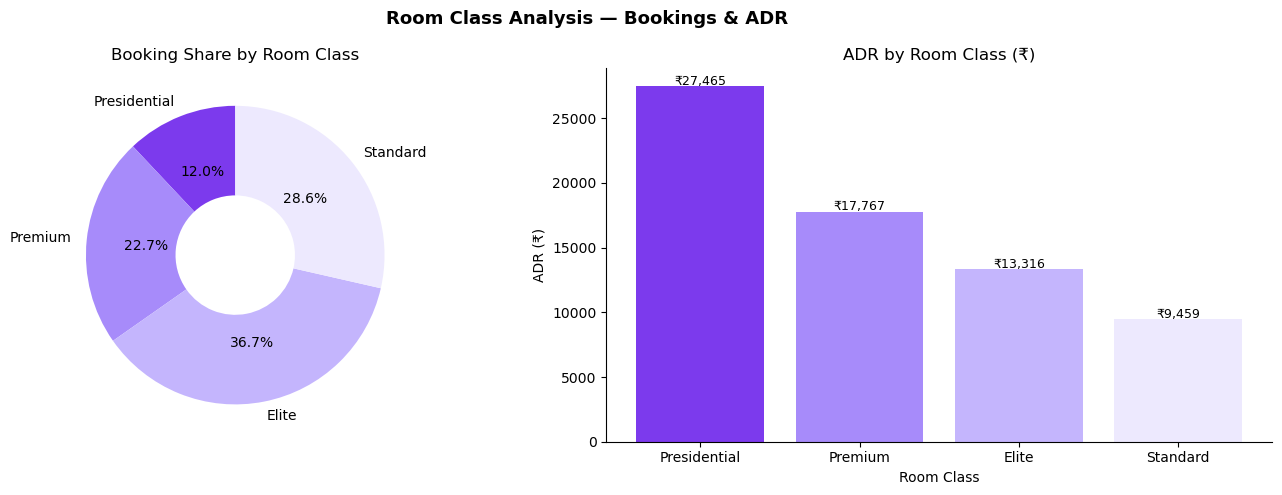

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart for bookings share
ax[0].pie(room_class_adr["total_bookings"],labels=room_class_adr["room_class"],autopct="%1.1f%%",
          colors=["#7c3aed","#a78bfa","#c4b5fd","#ede9fe"],startangle=90, wedgeprops=dict(width=0.6))
ax[0].set_title("Booking Share by Room Class")

# Bar chart for ADR
ax[1].bar(room_class_adr["room_class"],room_class_adr["ADR"],color=["#7c3aed","#a78bfa","#c4b5fd","#ede9fe"])
ax[1].set_title("ADR by Room Class (₹)")
ax[1].set_xlabel("Room Class")
ax[1].set_ylabel("ADR (₹)")

for i, v in enumerate(room_class_adr["ADR"]):
    ax[1].text(i, v + 100, f"₹{v:,.0f}", ha="center", fontsize=9)

ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

plt.suptitle("Room Class Analysis — Bookings & ADR", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**OBSERVATION**

**Presidential rooms** lead with the **highest ADR at ₹27,465** but show low demand with only **12% of total bookings**. **Elite rooms** dominate with the **highest booking share at 36.7%** despite a **lower ADR of ₹13,316**. This suggests most customers prefer mid-range options over premium ones — AtliQ should consider reviewing its Presidential room pricing or marketing strategy to improve demand.

In [91]:
# Occupancy % by hotel category

In [92]:
query_11 = """
SELECT 
    h.category AS hotel_category,
    ROUND((SUM(fa.successful_bookings)*1.0/SUM(fa.capacity))*100,1) AS Occupancy
FROM dim_hotels as h
JOIN fact_aggregated_bookings AS fa
ON h.property_id = fa.property_id
GROUP BY category
"""
hotel_category_Occupancy = pd.read_sql(query_11,conn)
hotel_category_Occupancy

,hotel_category,Occupancy
0,Business,58.2
1,Luxury,57.7


**Observation:**
Both hotel categories, Business and Luxury, show a similar occupancy rate of approximately 58%. Atliq needs to focus on improving overall occupancy.

In [93]:
# Realisation % by booking platform

In [94]:
# Overall realisation rate 
query_12 = """
SELECT 
    ROUND((SUM(revenue_realized)*1.0/SUM(revenue_generated)*100),1) AS Realisation_rate
FROM fact_booking
"""
Overall_realisation_rate = pd.read_sql(query_12,conn).iloc[0,0]
print(f"Overall realisation rate for AtliQ Hotels: {Overall_realisation_rate:,.1f}%")

Overall realisation rate for AtliQ Hotels: 85.1%


**OBSERVATION:**
The overall realisation rate is 85%, indicating a 15% potential revenue loss, primarily due to cancellations.

In [95]:
# Realisation % by booking platform
query_13 = """
SELECT
    booking_platform,
    COUNT(booking_id) AS booking_count,
    ROUND((SUM(revenue_realized)*1.0/SUM(revenue_generated)*100),1) AS Realisation_rate
FROM fact_booking
GROUP BY booking_platform
ORDER BY booking_count DESC
"""
booking_platform_realisation = pd.read_sql(query_13,conn)
booking_platform_realisation

,booking_platform,booking_count,Realisation_rate
0,others,55066,85.2
1,makeyourtrip,26898,84.9
2,logtrip,14756,85.5
3,direct online,13379,85.0
4,tripster,9630,85.0
5,journey,8106,85.0
6,direct offline,6755,85.2


**OBSERVATION:** All booking platforms have a similar realisation rate of around 85%

Text(0.5, 1.0, 'Booking Contribution by Platform (%)')

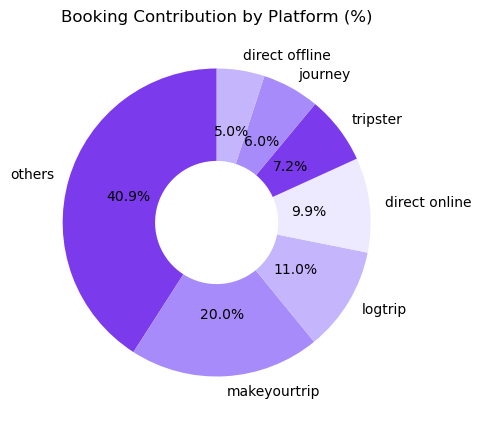

In [96]:
fig,ax = plt.subplots(figsize=(5,5))
ax.pie(booking_platform_realisation["booking_count"],
       labels = booking_platform_realisation["booking_platform"],
       autopct="%1.1f%%",
       colors=["#7c3aed","#a78bfa","#c4b5fd","#ede9fe"],
       startangle=90, wedgeprops=dict(width=0.6))
ax.set_title("Booking Contribution by Platform (%)")

**OBSERVATION:**
All booking platforms show a realisation rate close to 85%, with minimal variation. Additionally, **platforms like “others” and “makeyourtrip”** contribute the highest booking volumes, making them key drivers of overall revenue.

In [97]:
# Revenue leakage — cancellations

In [98]:
query_14 = """
SELECT 
    SUM(revenue_generated) - SUM(revenue_realized) AS Revenue_leakage,
    ROUND(
        (SUM(revenue_generated) - SUM(revenue_realized)) * 1.0 / SUM(revenue_generated) * 100, 1) AS Leakage_pct
FROM fact_booking
"""
Revenue_leakage = pd.read_sql(query_14, conn)
Revenue_leakage

,Revenue_leakage,Leakage_pct
0,298774986,14.9


In [99]:
query_15 = """
SELECT 
    booking_status,
    SUM(revenue_generated) - SUM(revenue_realized) AS Revenue_leakage,
    ROUND(
        (SUM(revenue_generated) - SUM(revenue_realized)) * 1.0 / SUM(revenue_generated) * 100, 1) AS Leakage_pct
FROM fact_booking
GROUP BY booking_status

"""
Revenue_leakage_Booking_Status = pd.read_sql(query_15,conn)
Revenue_leakage_Booking_Status

,booking_status,Revenue_leakage,Leakage_pct
0,Cancelled,298774986,60.0
1,Checked Out,0,0.0
2,No Show,0,0.0


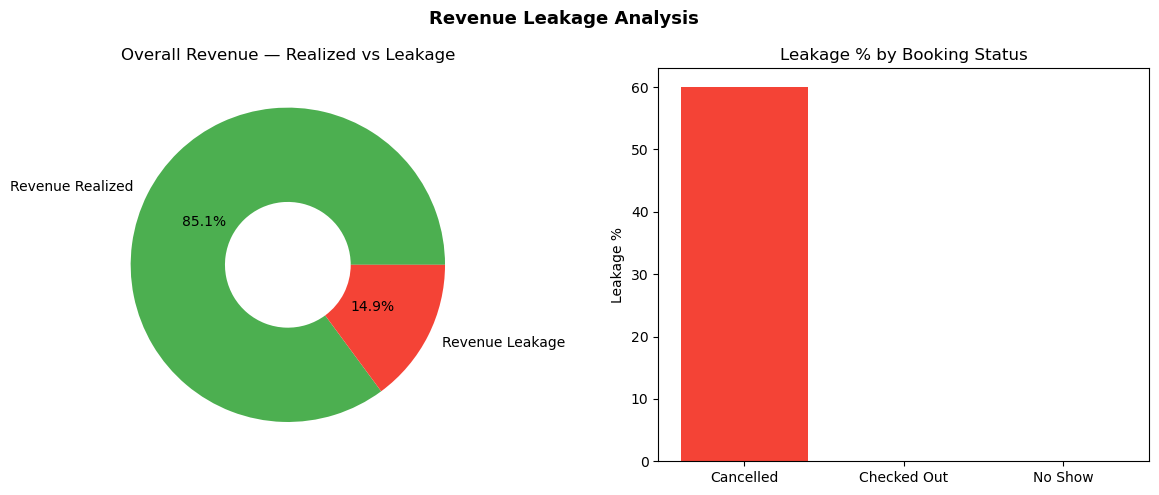

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — Overall leakage vs recovered
labels = ["Revenue Realized", "Revenue Leakage"]
values = [
    fact_booking["revenue_realized"].sum(),
    fact_booking["revenue_generated"].sum() - fact_booking["revenue_realized"].sum() 
]
axes[0].pie(values, labels=labels, autopct="%1.1f%%",
            colors=["#4CAF50", "#F44336"],
            wedgeprops=dict(width=0.6))
axes[0].set_title("Overall Revenue — Realized vs Leakage")


# Right — Leakage by booking status
axes[1].bar(Revenue_leakage_Booking_Status["booking_status"],
            Revenue_leakage_Booking_Status["Leakage_pct"],
            color=["#F44336", "#4CAF50", "#FF9800"])
axes[1].set_title("Leakage % by Booking Status")
axes[1].set_ylabel("Leakage %")



plt.suptitle("Revenue Leakage Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**OBSERVATION:**

1. AtliQ Hotels experienced an **overall revenue leakage of ₹2988 Lakhs — 14.9% of total generated revenue**. 
2. Breakdowns by booking status reveals that **100% of leakage is driven by Cancelled bookings**, which lose **60%** of their expected revenue — recovering only 40% through cancellation penalties.
3. Checked Out and No Show bookings show zero leakage. This means **reducing cancellation rate is the single most impactful action** AtliQ can take to recover lost revenue.

In [101]:
# Cancellation Rate by City (NOT COUNT)
query_15_1 = """
SELECT 
    d.city as city,
    COUNT(*) AS Total_booking,
    SUM(CASE WHEN f.booking_status = 'Cancelled' THEN 1 ELSE 0 END ) AS Cancelled,
    ROUND(SUM(CASE WHEN f.booking_status = 'Cancelled' THEN 1 ELSE 0 END )*100.0 / COUNT(*),2) AS Cancel_rate
FROM dim_hotels d
JOIN fact_booking f
ON d.property_id = f.property_id
GROUP BY d.city 
ORDER BY Cancel_rate DESC;
"""

Cancellation_rate_by_city   = pd.read_sql(query_15_1,conn)
Cancellation_rate_by_city

,city,Total_booking,Cancelled,Cancel_rate
0,Delhi,24231,6072,25.06
1,Bangalore,32016,8002,24.99
2,Mumbai,43455,10754,24.75
3,Hyderabad,34888,8592,24.63


In [102]:
# Cancellation Rate by Platfrom (NOT COUNT)
query_15_2 = """
SELECT 
    booking_platform,
    COUNT(*) AS Total_booking,
    SUM(CASE WHEN booking_status = "Cancelled" THEN 1 ELSE 0 END) AS Cancelled,
    ROUND(SUM(CASE WHEN booking_status='Cancelled' THEN 1 ELSE 0 END) *100.0/COUNT(*),2) AS Cancel_rate
FROM fact_booking
GROUP BY booking_platform
ORDER BY Cancel_rate DESC;
"""
Cancellation_rate_by_platfrom  = pd.read_sql(query_15_2,conn)
Cancellation_rate_by_platfrom

,booking_platform,Total_booking,Cancelled,Cancel_rate
0,tripster,9630,2407,24.99
1,makeyourtrip,26898,6722,24.99
2,direct online,13379,3344,24.99
3,others,55066,13698,24.88
4,journey,8106,2009,24.78
5,direct offline,6755,1654,24.49
6,logtrip,14756,3586,24.30


In [103]:
# Cancellation Rate by property (NOT COUNT)
query_15_3 = """
SELECT 
    d.property_name as property_name,
    COUNT(*) AS Total_booking,
    SUM(CASE WHEN f.booking_status = 'Cancelled' THEN 1 ELSE 0 END ) AS Cancelled,
    ROUND(SUM(CASE WHEN f.booking_status = 'Cancelled' THEN 1 ELSE 0 END )*100.0 / COUNT(*),2) AS Cancel_rate
FROM dim_hotels d
JOIN fact_booking f
ON d.property_id = f.property_id
GROUP BY d.property_name 
ORDER BY Cancel_rate DESC;
"""

Cancellation_rate_by_property   = pd.read_sql(query_15_3,conn)
Cancellation_rate_by_property

,property_name,Total_booking,Cancelled,Cancel_rate
0,Atliq Palace,23625,5949,25.18
1,Atliq Grands,17035,4273,25.08
2,Atliq City,23323,5811,24.92
3,Atliq Bay,21389,5314,24.84
4,Atliq Seasons,3982,987,24.79
5,Atliq Blu,21795,5373,24.65
6,Atliq Exotica,23441,5713,24.37


In [104]:
# Cancellation Rate by category (NOT COUNT)
query_15_4 = """
SELECT 
    d.category as category,
    COUNT(*) AS Total_booking,
    SUM(CASE WHEN f.booking_status = 'Cancelled' THEN 1 ELSE 0 END ) AS Cancelled,
    ROUND(SUM(CASE WHEN f.booking_status = 'Cancelled' THEN 1 ELSE 0 END )*100.0 / COUNT(*),2) AS Cancel_rate
FROM dim_hotels d
JOIN fact_booking f
ON d.property_id = f.property_id
GROUP BY d.category 
ORDER BY Cancel_rate DESC;
"""

Cancellation_rate_by_category   = pd.read_sql(query_15_4,conn)
Cancellation_rate_by_category

,category,Total_booking,Cancelled,Cancel_rate
0,Business,50930,12747,25.03
1,Luxury,83660,20673,24.71


Text(0, 0.5, 'Cancel rate %')

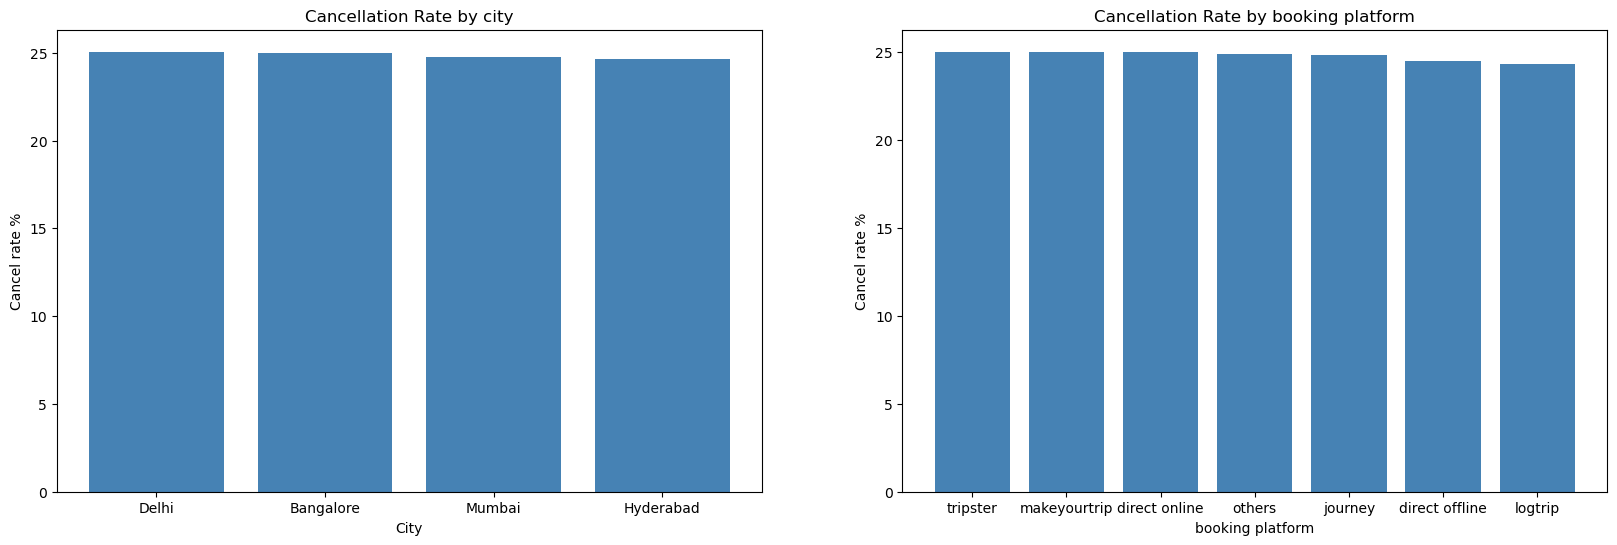

In [105]:
fig,ax = plt.subplots(1,2,figsize=(20,6))

ax[0].bar(Cancellation_rate_by_city["city"],Cancellation_rate_by_city["Cancel_rate"],color = "steelblue")
ax[0].set_title("Cancellation Rate by city")
ax[0].set_xlabel("City")
ax[0].set_ylabel("Cancel rate %")

ax[1].bar(Cancellation_rate_by_platfrom["booking_platform"],Cancellation_rate_by_platfrom["Cancel_rate"],color = "steelblue")
ax[1].set_title("Cancellation Rate by booking platform")
ax[1].set_xlabel("booking platform")
ax[1].set_ylabel("Cancel rate %")


**OBSERVATION**
Cancellation rate remains consistently high (~24–25%) across all cities and booking platforms, indicating a system-wide issue rather than segment-specific variation. 

In [106]:
# Weekend vs Weekday

In [107]:
query_16 = """
SELECT 
    d.day_type,
    SUM(f.revenue_realized)/100000 AS Total_revenue_realized_lakhs
FROM dim_date AS d
JOIN fact_booking AS f
ON d.date = f.check_in_date
GROUP BY day_type
"""
revenue_day_type = pd.read_sql(query_16,conn)
revenue_day_type

,day_type,Total_revenue_realized_lakhs
0,Weekday,11848
1,Weekend,5239


In [108]:
query_17 = """
SELECT
    d.day_type,
    COUNT(f.booking_id) AS total_booking,
    SUM(revenue_realized)/100000 AS total_revenue_lakhs,
    ROUND(SUM(f.revenue_realized)*1.0/COUNT(f.booking_id),1) AS ADR,
    ROUND(SUM(f.revenue_realized)*1.0/SUM(f.revenue_generated), 2) AS realisation_pct
FROM dim_date as d
JOIN fact_booking as f
ON d.date = f.check_in_date
GROUP BY day_type

"""
weekday_vs_weekend = pd.read_sql(query_17,conn)
weekday_vs_weekend

,day_type,total_booking,total_revenue_lakhs,ADR,realisation_pct
0,Weekday,93416,11848,12683.2,0.85
1,Weekend,41174,5239,12725.5,0.85


Text(0.5, 1.0, 'ADR')

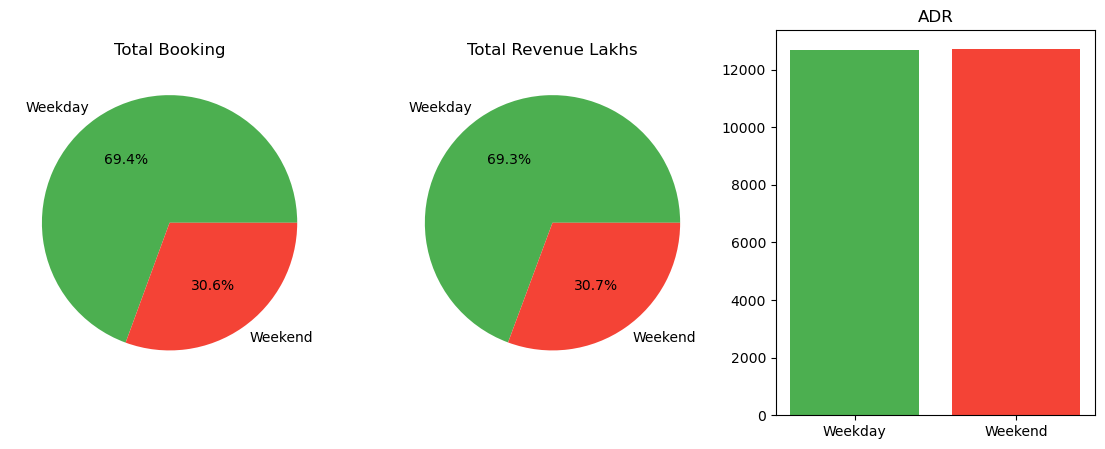

In [109]:
fig,ax = plt.subplots(1,3,figsize=(14,5))

ax[0].pie(weekday_vs_weekend["total_booking"],
          labels=weekday_vs_weekend["day_type"],
         autopct="%1.1f%%",colors=["#4CAF50", "#F44336"])
ax[0].set_title("Total Booking")

ax[1].pie(weekday_vs_weekend["total_revenue_lakhs"],
          labels=weekday_vs_weekend["day_type"],
         autopct="%1.1f%%",colors=["#4CAF50", "#F44336"])
ax[1].set_title("Total Revenue Lakhs")

ax[2].bar(weekday_vs_weekend["day_type"],
          weekday_vs_weekend["ADR"],
          color=["#4CAF50", "#F44336"])
ax[2].set_title("ADR")
          

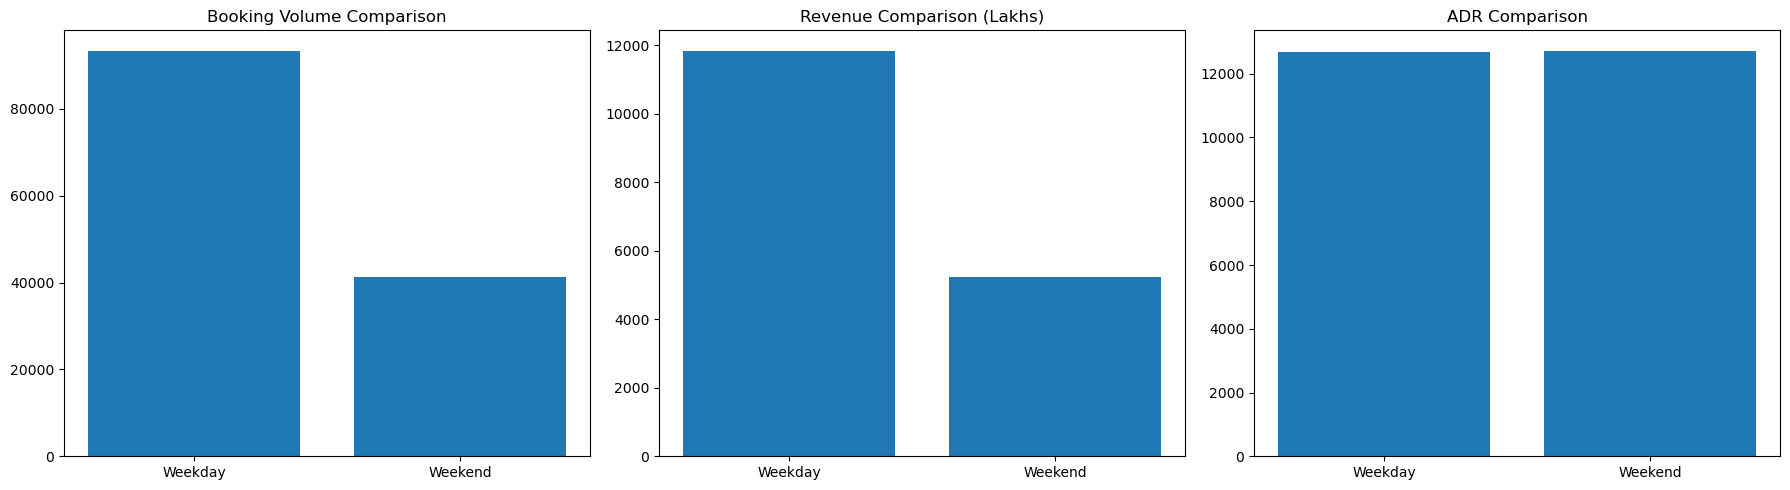

In [110]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

# Booking Comparison
ax[0].bar(weekday_vs_weekend["day_type"], weekday_vs_weekend["total_booking"])
ax[0].set_title("Booking Volume Comparison")

# Revenue Comparison
ax[1].bar(weekday_vs_weekend["day_type"], weekday_vs_weekend["total_revenue_lakhs"])
ax[1].set_title("Revenue Comparison (Lakhs)")

# ADR Comparison‹
ax[2].bar(weekday_vs_weekend["day_type"], weekday_vs_weekend["ADR"])
ax[2].set_title("ADR Comparison")

plt.tight_layout()

**Observation** - Weekday vs Weekend Analysis

1. Booking volume and revenue are stable and predictable across both day types — weekdays contribute ~69% and weekends ~31%, which aligns proportionally with the number of weekday vs weekend days in the dataset.

2. ADR is nearly identical — Weekday ₹12,683 vs Weekend ₹12,725 — showing AtliQ currently applies no dynamic pricing strategy.

3. AtliQ is not utilizing higher weekend demand effectively due to lack of dynamic pricing, resulting in missed revenue opportunities.

4. Business Recommendation:
- Weekends: AtliQ should implement premium/surge pricing on weekends since demand exists — higher ADR can directly boost revenue without needing  more bookings.
- Weekdays: Focus on discounts, corporate tie-ups, or offers to drive higher occupancy during weekdays.

In [111]:
# Monthly Trend
query_18 = """
SELECT 
    STRFTIME('%m', check_in_date) AS month_number,
    SUM(revenue_generated)/100000 AS revenue_generated_lakhs,
    SUM(revenue_realized)/100000 AS revenue_realized_lakhs,
    ROUND((SUM(revenue_realized)*1.0/SUM(revenue_generated)*100),1) AS Realisation_rate
FROM fact_booking
GROUP BY month_number
"""

monthly_trend = pd.read_sql(query_18,conn)
monthly_trend["MoM_pct_change"] = monthly_trend["revenue_realized_lakhs"].pct_change()*100
monthly_trend["MoM_pct_change"] = round(monthly_trend["MoM_pct_change"],1)
monthly_trend

,month_number,revenue_generated_lakhs,revenue_realized_lakhs,Realisation_rate,MoM_pct_change
0,05,6838,5819,85.1,NaN
1,06,6519,5539,85.0,-4.8
2,07,6717,5729,85.3,3.4


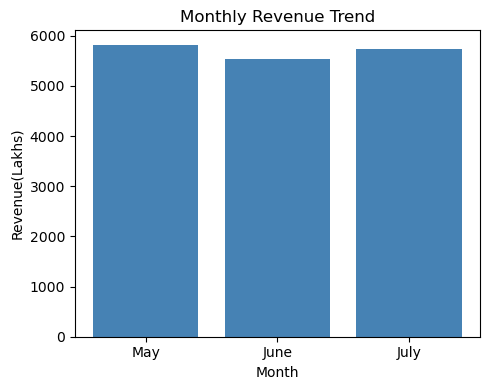

In [112]:
fig,ax = plt.subplots(figsize=(5,4))
ax.bar(monthly_trend["month_number"],monthly_trend["revenue_realized_lakhs"],color = 'steelblue')
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue(Lakhs)")
ax.set_xticks(monthly_trend["month_number"])
ax.set_xticklabels(['May', 'June', 'July'])

plt.tight_layout()
plt.show()

**OBSERVTAION :**
From May to July, revenue remains consistent, staying **above 5500 lakhs each month**. However, there is a slight decline of around 4.8% from May to June, followed by a recovery with a 3.4% increase from June to July,indicating short-term fluctuation rather than a strong trend.

In [113]:
query_19 = """
SELECT 
    d.week_no AS week_number,
    COUNT(f.booking_id) AS total_bookings,
    SUM(revenue_generated)/100000 AS revenue_generated_lakhs,
    SUM(revenue_realized)/100000 AS revenue_realized_lakhs
FROM fact_booking as f
JOIN dim_date as d
ON f.check_in_date = d.date
GROUP BY week_number
"""
weekly_trend = pd.read_sql(query_19,conn)
weekly_trend

,week_number,total_bookings,revenue_generated_lakhs,revenue_realized_lakhs
0,W 19,10965,1631,1381
1,W 20,10958,1632,1394
2,W 21,9042,1347,1149
3,W 22,10934,1635,1387
4,W 23,9089,1352,1155
5,W 24,11041,1646,1395
6,W 25,10943,1635,1386
7,W 26,9017,1345,1141
8,W 27,10962,1636,1395
9,W 28,10929,1631,1393


In [114]:
dim_date[dim_date["week_no"]=="W 32"]

,date,mmm yy,week_no,day_type
91,2022-07-31,Jul 22,W 32,Weekday


In [125]:
# Exclude W32 — incomplete week
weekly_trend = weekly_trend[~(weekly_trend["week_number"]== "W 32")]
weekly_trend.tail(5)

,week_number,total_bookings,revenue_generated_lakhs,revenue_realized_lakhs
8,W 27,10962,1636,1395
9,W 28,10929,1631,1393
10,W 29,11018,1644,1397
11,W 30,9020,1344,1148
12,W 31,9021,1346,1150


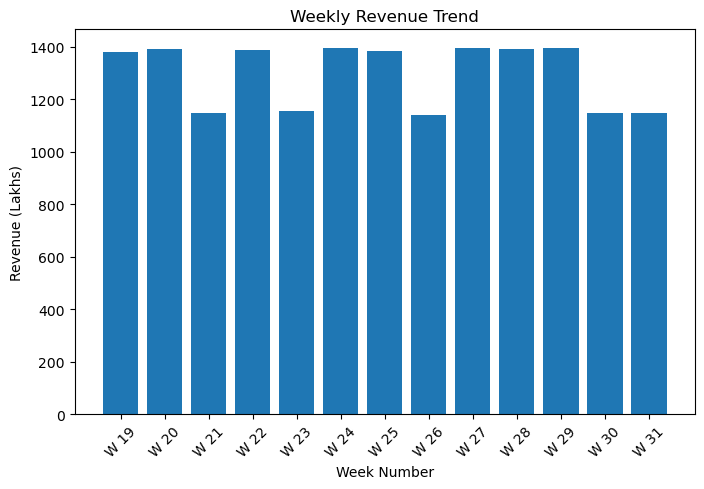

In [116]:
plt.figure(figsize=(8,5))

plt.bar(weekly_trend["week_number"],
         weekly_trend["revenue_realized_lakhs"])

plt.title("Weekly Revenue Trend")
plt.xlabel("Week Number")
plt.ylabel("Revenue (Lakhs)")
plt.xticks(rotation=45)

plt.show()

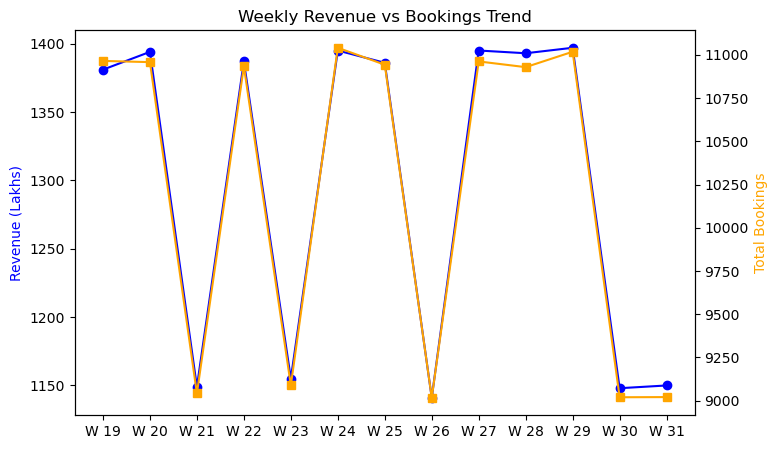

In [117]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Revenue
ax1.plot(weekly_trend["week_number"],
         weekly_trend["revenue_realized_lakhs"],
         color='blue', marker='o')
ax1.set_ylabel("Revenue (Lakhs)", color='blue')

# Bookings (secondary axis)
ax2 = ax1.twinx()
ax2.plot(weekly_trend["week_number"],
         weekly_trend["total_bookings"],
         color='orange', marker='s')
ax2.set_ylabel("Total Bookings", color='orange')

plt.title("Weekly Revenue vs Bookings Trend")
plt.xticks(rotation=45)
plt.show()

**OBSERVATION:**
Weekly revenue is mostly stable around 1350–1400 lakhs and does not show any strong increasing or decreasing trend. However, in some weeks like W21, W23, W26, W30, and W31, there is a clear drop in revenue to around 1140–1150 lakhs.
Also, revenue and bookings follow almost the same pattern, which shows that revenue changes are mainly driven by booking fluctuations.

### DATA EXPORT — Power BI
Exporting cleaned dataframes as CSVs for Power BI dashboard.

In [127]:
# Export cleaned data for Power BI
dim_hotels.to_csv("clean_dim_hotels.csv", index=False)
dim_rooms.to_csv("clean_dim_rooms.csv", index=False)
dim_date.to_csv("clean_dim_date.csv", index=False)
fact_booking.to_csv("clean_fact_booking.csv", index=False)
fact_aggregated_bookings.to_csv("clean_fact_aggregated_bookings.csv", index=False)

---
### 💼 Business Recommendations

#### 1. Weekday and Weekend Rates Are Identical — Revenue Opportunity Being Missed (Priority: High)

- Weekday ADR (₹12,683) and Weekend ADR (₹12,725) are almost identical — meaning AtliQ 
  is charging the same price on a Saturday as Tuesday.
- This is a missed opportunity. Weekend demand is already there, so AtliQ can charge 
  10–15% more on Friday and Saturday without losing bookings.
- On slower weekdays, a slight discount or corporate rate can help pull occupancy up 
  from the current 57.9%.

---

#### 2. 24–25% Cancellation Rate Is Draining ₹2,988 Lakhs in Revenue (Priority: High)

- Cancellation rate is ~24–25% across every city and every platform — this is not a 
  location problem, it's a policy problem.
- Because of this, AtliQ is losing ₹2,988 Lakhs — nearly 15% of expected revenue.
- The fix is a basic tiered policy:
  - Full refund if cancelled 7+ days before check-in
  - 50% refund between 3–7 days
  - No refund within 3 days
- This is standard practice in the hotel industry and would directly reduce leakage 
  without scaring away bookings.

---

#### 3. Delhi and Hyderabad Are Underperforming at Property Level (Priority: Medium)

- As compared to Mumbai (₹835.75L per property), Delhi has 29.5% and Hyderabad has 
  35.1% per-property revenue gap. Both cities need separate focus — a general 
  company-wide strategy will not work here.
- Delhi is mostly a corporate and political hub. So AtliQ should target corporate 
  people specifically — things like meeting room packages, short stay options, corporate 
  tie-ups with companies and government offices. That kind of demand already exists in 
  Delhi, AtliQ just needs to capture it.
- Hyderabad has a large and growing tech sector with companies regularly sending 
  employees for project-based stays. AtliQ should offer monthly and extended-stay 
  packages at a competitive rate. For a company, booking a hotel room on a monthly 
  package is easier and often cheaper than arranging employee accommodation — AtliQ 
  can position itself as that solution.

---

#### 4. Presidential Rooms Have Highest Price but Lowest Demand (Priority: Medium)

- Presidential rooms have the highest ADR at ₹27,465 but only 12% of total bookings — 
  which is the lowest among all room classes.
- Elite rooms at ₹13,316 are getting 36.7% bookings. So customers are clearly choosing 
  mid-range over premium.
- This means either the price is too high for what AtliQ is offering, or guests don't 
  see enough value in paying that much extra.
- AtliQ has two options here — either bring the price down a bit to attract more 
  bookings, or add something concrete to justify that premium like private dining, 
  butler service, or exclusive floor access.
- Just keeping a high price without giving guests a clear reason to pay for it is not 
  working right now.

---

#### 5. Occupancy Improvement — Linked to Above Recommendations

- Overall occupancy is at 57.9% — meaning 42% of available rooms are going 
  empty every night.
- This is not listed as a separate action item because it is a direct outcome 
  of the above four points:
  - Weekday discounts will pull more bookings on slower days
  - Fewer cancellations means more rooms actually occupied
  - City-specific packages in Delhi and Hyderabad will drive demand in 
    underperforming markets
  - Fixing Presidential room pricing will fill currently empty premium rooms
- If the above recommendations are implemented, occupancy improvement 
  will follow automatically.

### ✅ Conclusion

1. AtliQ Grands is a fundamentally viable hotel chain — revenue realization of 85.1% 
   and stable weekly trends confirm the business is operational.

2. However, three structural problems are preventing growth: a 24–25% cancellation 
   rate draining ₹2,988 Lakhs (nearly 15% of expected revenue), below-target occupancy 
   at 57.9% across all categories, and significant property-level underperformance in 
   Delhi and Hyderabad.

3. Addressing these through a revised cancellation policy, dynamic pricing strategy, 
   and city-specific revenue plans can meaningfully recover market share.